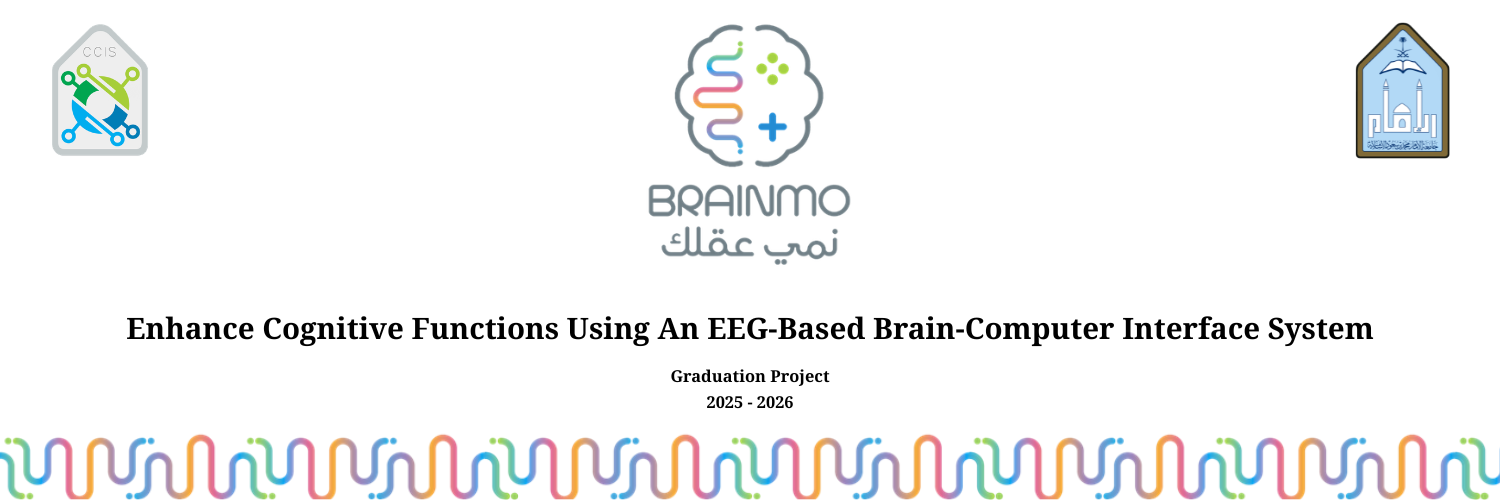

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Before feeding the EEG data into the  Algorithms, the data will be preprocessed through the following pipeline, common average re-referencing, bandpass filtering using fourth-order Chebyshev Type II filter (0.5-50 Hz), down sampling to 200 Hz, ICA decomposition, labeling artifacts using ICLabel and excluding all components except the brain such as: eye blinks and muscle artifacts.

# **Workflow Guidelines** (March 7, 2026)
* Filter out unwanted frequency bands, retaining only those within the 8-32 range.
* Remove the baseline channels.
* Prepare the ICA
* Prepare ICALabel to distinguish independent components (ICs)





Notes:
MNE
https://mne.tools/stable/auto_tutorials/simulation/10_array_objs.html


#1- **Environment Setup**

##1.1 Installation and Importing Libraries

In [ ]:
!pip install moabb #Install MOABB benchmark
!pip install mne
!pip install mne-icalabel
!pip install scipy pandas scikit-learn matplotlib spectrum

import matplotlib.pyplot as plt
from scipy.signal import lfilter, freqz
from spectrum import arburg
import os

In [ ]:
import mne
import numpy as np
from mne_icalabel import label_components
import matplotlib.pyplot as plt
from scipy.signal import lfilter, freqz
import os

In [ ]:
# import matplotlib.pyplot as plt
# from scipy.signal import lfilter, freqz
# from spectrum import arburg
# import os

#

##1.2- Access and Loading The Raw Data

In [ ]:
from moabb.datasets import Shin2017B #import the dataset 'Shin2017B'
dataset = Shin2017B()
dataset.accept = True # accept licenses
dataset.download()

#Dataset Info:
#1) Each session comprised a 1 min pre-experiment resting period
#2) 20 repetitions of the given task
#3) 1 min post-experiment resting period.
#4) The task started with 2 s of a visual introduction of the task, followed by 10 s of a task period and resting period which was given randomly from 15 to 17 s

In [ ]:
print(dataset.event_id)

In [ ]:
from scipy import signal

In [ ]:
def preprocess_raw(raw_data, n_components ,random_state , max_iter , components ):

#Step
    raw_data.set_eeg_reference(ref_channels='average')

    # create the fourth-order Chebyshev II filter
    sos = signal.cheby2(N=4,rs=40, Wn= [0.5 , 50],btype = "bandpass" ,fs = 200 , output='sos' )
    data = raw_data.get_data(picks='eeg')
    # axsis x repreesnts the time points
    sos_filter= signal.sosfiltfilt(sos, data, axis= 1)

    index = mne.pick_types(raw_data.info ,eeg=True)
    raw_data._data[index] = sos_filter
    #------------------------------------------------------------
    raw_data.resample(200)
    preprocess_ica(raw_data , n_components ,random_state , max_iter , components )
#Step
    #emotive channels are : [AF3, F7, F3, FC5, T7, P7, O1, O2, P8, T8, FC6, F4, F8, AF4] that we will use to record our particepents
    #The channels that we want to study ['F3', 'F4', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Stim']
    #raw_data.pick(channels)
    return raw_data


def preprocess_ica(raw_data , n_components ,random_state , max_iter , components ):
    ica = mne.preprocessing.ICA(n_components= n_components, random_state = random_state, max_iter = max_iter)
    ica.fit(raw_data)
    #ica.plot_components()
#Step : by Iclabel
    ic_labels = label_components(raw_data, ica, method="iclabel")

    print(ic_labels["labels"])
    ica.plot_properties(raw_data, picks= components, verbose=False)
    labels = ic_labels["labels"]
    exclude_idx = [
    idx for idx, label in enumerate(labels) if label not in ["brain", "other"]
      ]
    print(f"Excluding these ICA components: {exclude_idx}")

    ica.exclude = exclude_idx
    ica.apply(raw_data)




#Fast run

In [ ]:
from google.colab import drive
# import os
# import mne

drive.mount('/content/drive')

save_folder = '/content/drive/My Drive/EEG_Processed_Data/'

if not os.path.exists(save_folder):
    os.makedirs(save_folder)

In [ ]:
subject_ids = dataset.subject_list
subjects_trials = {}

for subject_id in subject_ids:

    file_path = f"{save_folder}sub_{subject_id}-epo.fif"

    if os.path.exists(file_path):
        print(f"Loading Subject {subject_id} from Drive...")
        epochs = mne.read_epochs(file_path, preload=True)
    else:
        print(f"Processing Subject {subject_id} (This may take a while)...")
        subject_raw_data = []
        subject_data = dataset.get_data(subjects=[subject_id])
        sessions = subject_data[subject_id].keys()

        for session in sessions:
            raw_data = subject_data[subject_id][str(session)]['0']
            raw_data = preprocess_raw(raw_data,7, 97, 800, [0, 6])
            subject_raw_data.append(raw_data)

        combined_raws = mne.concatenate_raws(subject_raw_data)
        del subject_raw_data

        events = mne.find_events(combined_raws, stim_channel="Stim")
        epochs = mne.Epochs(combined_raws, events, tmin=-1.0, tmax=9.0, preload=True)
        epochs.crop(tmin=1.0, tmax=10.0)
        epochs.save(file_path, overwrite=True)
        print(f"Subject {subject_id} processed and saved.")

    subjects_trials[subject_id] = {
        'rest': epochs['4'],
        'subtraction': epochs['3']
    }

    msg = f"** Note: subject No.{subject_id }\nData has been processed for all three sessions and cropped based on events:\n1- Rest\n2- Subtraction"

    print(f"\033[92m{msg}\033[0m\n");





In [ ]:
# Test the function with debugging
print("\nTesting load_subject_data with verification...\n")
X_att   = subjects_trials[1]['subtraction'].get_data(picks = ['eeg'])
X_inatt = subjects_trials[1]['rest'].get_data(picks = ['eeg'])

print(f"\033[1mAttentional trials:\033[0m {len(X_att)}")
print(f"\033[1mInattentional trials:\033[0m {len(X_inatt)}")

# Check data actual content
if len(X_att) > 0:
    print(f"\033[1mAttentional trial shape:\033[0m {X_att[0].shape}")
    print(f"\n\n\033[1mAttentional trial data sample:\033[0m \n{X_att[0]}")
    print(f"\n\n\033[1mAttentional trial min/max values:\033[0m\n {X_att[0].min():.4e} / {X_att[0].max():.4e}")# we use e not f cus its small values

if len(X_inatt) > 0:
    print(f"\033[1mInattentional trial shape:\033[0m \n{X_inatt[0].shape}")
    print(f"\033[1mInattentional trial data sample (first 5 values):\033[0m \n{X_inatt[0][0, :5]}")

DO i need to mention why i choes order = 16?



$\text{from the foolow}$
$$\text{Frequency Resolution} = \frac{\text{Sampling Frequency}}{\text{Number of Data Points}}$$

$$NFFT = \frac{\text{Sampling Frequency}}{\text{Frequency Resolution}}$$


Chen, Rujun. (2015). Re: How can I define the frequency resolution in FFT? And what is the difference on interpreting the results between high and low frequency resolution?. Retrieved from: https://www.researchgate.net/post/How-can-I-define-the-frequency-resolution-in-FFT-And-what-is-the-difference-on-interpreting-the-results-between-high-and-low-frequency-resolution/55d5eaa06225ff9e298b45bb/citation/download.

In [ ]:
from spectrum import pburg

In [ ]:
def compute_psd(epoch,order =18):# takes epoch with shape (30,40)
  psd_values_array = [] # to store the psd values

  data = np.asarray(epoch) #gets the data from the subject raw object
  n_channels = data.shape[0] #how many channels i need to read:  (channels =30, time points =1606)

  data = data * 1e6 #the values are near to the zero so scale up by converting unit of the data (V to μV) ot
  #data += np.random.normal(0, 1e-6, data.shape) # to avoid (Rank Deficienc)we need to add noise around the zero so the signls does not affected

#___________________________________________________________________________________________________________________________________________________________________

  for channel in range(n_channels): #from 0 to 30
    data_sample = data[channel, : ]

    pburg_model = pburg(data_sample.flatten(), order ,sampling = 200, scale_by_freq=True ,NFFT= 2000 )
    psd_values_array.append(pburg_model.psd)


  freq_values = np.array(pburg_model.frequencies()) #get the  frequencies for all channel are the same

  mask = (freq_values >= 1) & (freq_values <= 29) # The frequency range from 1 Hz to 29 Hz is considered which covers the α, β and θ bands
  freq_values = freq_values[mask]

  psd_values_array = np.array(psd_values_array)
  psd_values_array = psd_values_array[:,mask] # for all channels keep the accpected values in mask
  return psd_values_array , freq_values


#Window sampling function

In [ ]:
def window_sampling(trail_data): #data has 1 trils
  window_size = 2 * 200 #freqs * 2's
  step_size = 0.5 * 200 #freqs
  time_points = trail_data.shape[1]
  #print(data.shape) # (30, 1601)

  epochs = []

  for start in range(0, time_points - window_size + 1, int(step_size)):
    epoch = trail_data[:, start : start + window_size] #[start , start + window_size) with shape (30 channel , 400 time points)
    epochs.append(epoch)
  return epochs # for each trail we return a list contais all the samples of that trail


#Example Based on subject from Moabb:

Each subject has 30 trials, each trial has a shape(30,1601)

after applying window sampling

each trail will break down into 13 windows (13,30,400)

each window has the shape of (30,400)

for each subject we want 30 * 13 = 390 sample

so as an output of (window sampling): we want to return a list that contains 390 sample


$$R(f) = \frac{mean\_psd\_inatt}{mean\_psd\_att}$$


In [ ]:

waight_matrix = {}
def compute_weight(ratio, subject_id):

  waight_matrix[subject_id] = {}
  #Step1: extract the indices
  f_plus_indices = np.where(ratio > 1)[0]
  f_minus_indices = np.where(ratio < 1)[0]

  #

  #Step 2 :
  weight =np.abs(ratio - 1)
  #Step 3 : extract the frequnceies in the extracte indices
  f_plus_vals = weight[f_plus_indices]
  f_minus_vals = weight[f_minus_indices]


  waight_matrix[subject_id] = {
      'f_plus_vals':f_plus_vals,
      'f_minus_vals': f_minus_vals,
      'f_plus_indices': f_plus_indices,
      'f_minus_indices': f_minus_indices,

    }
  return waight_matrix[subject_id]



In [ ]:
def plot_channel_ratio(freqs, ratio_matrix, subject_id):
    import os
    freqs = np.array(freqs)
    # The frequency range from 1 Hz to 29 Hz is considered
    # which covers the α, β and θ bands, while the size of a frequency component is 0.1 Hz. thats why NFFT needs to be 2048


    plt.figure(figsize=(12, 6))

    plt.axvspan(8, 13, alpha=0.3, color='skyblue', label='Alpha band (8-13 Hz)')
    plt.axvspan(13, 22, alpha=0.3, color='palegreen', label='Beta band (13-22 Hz)')

    plt.plot(freqs, ratio_matrix, color='black', linewidth=2, label='Average R(f)')  #draw the frequencies

    # draw the  Threshold line
    plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Threshold (R(f)=1)')

    plt.ylim(0, np.percentile(ratio_matrix , 99) * 1.5)
    plt.title(f'Subject-Specific Change Pattern R(f) - Subject {subject_id} Average', fontsize=14)
    plt.xlabel('Frequency (Hz)', fontsize=12)
    plt.ylabel('Ratio P_att / P_inatt', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.4)
    plt.legend()
    plt.show()

In [ ]:
# from typing_extensions import final
# import numpy as np
# import mne
# import matplotlib.pyplot as plt
# from scipy import signal
# from spectrum import pburg


def calculate_ratio(mean_psd_att,mean_psd_inatt):
  epsilon_float64 = np.finfo(np.float64).eps # to avoid devide on zero
  ratio = np.divide(mean_psd_att, mean_psd_inatt,
                      out=np.ones_like(mean_psd_att), # the 1 value will be canceld once the weight is calculated since (r(f) -1 )
                      where=mean_psd_inatt > epsilon_float64) # 64 machine epsilon value is 2.2x e-16
  return ratio


def subject_weight_matrix (subject_id, start, end ):

    print(f"Starting Algorithm 1 for Subject: {subject_id}...")

    #(Attentional vs Inattentional)
    X_att = subjects_trials[subject_id]['subtraction'][0: 16].get_data(picks=['eeg'])
    X_inatt = subjects_trials[subject_id]['rest'][0: 16].get_data(picks=['eeg'])

    # Step 1 : sample the trail into windoes
    window_wise_average_PSD_att = []
    window_wise_average_PSD_natt = []
    trails_ratio = []

    for trial in range(X_att.shape[0]):
        att_samples = window_sampling(X_att[trial])
        inatt_samples = window_sampling(X_inatt[trial])
        # Step2 : Calculate PSD for each data sample in the current trail

        channel_wise_average_PSD_att = []
        channel_wise_average_PSD_inatt = []

        for sample in range(len( att_samples )):

          p_att, freqs = compute_psd( att_samples [sample])
          p_inatt, _ = compute_psd(inatt_samples[sample])

          #Step 3 :  Calculate the channel-wise average PSD

          channel_wise_average_PSD_att.append(np.mean(p_att, axis=0))
          channel_wise_average_PSD_inatt.append(np.mean(p_inatt, axis=0))

      #Step 4 : Calculate the time window-wise average PSD functions (averge of each trail)
        window_wise_average_PSD_att = np.mean(channel_wise_average_PSD_att, axis=0)
        window_wise_average_PSD_natt = np.mean(channel_wise_average_PSD_inatt, axis=0)
      # Step 5 :Calculate Ratio R(f) for each trail
        ratio = calculate_ratio(window_wise_average_PSD_att,window_wise_average_PSD_natt)
        trails_ratio.append(ratio)
    # step6 : Calculate the trial-wise average ratio R(f) of PSD functions
    final_ratio = np.mean(trails_ratio, axis=0)

   # Outpot: the weight matrix for each subject based on the raito matrix
    weight_matrix = compute_weight(final_ratio, subject_id)

    return  {
        'subject_id': subject_id,
        'weight matrix': weight_matrix,
        'freqs': freqs,
        'ratio': final_ratio
      }


In [ ]:
from joblib import Parallel, delayed

In [ ]:
subjects_weight_matrix = Parallel(n_jobs=-1, verbose=10)(
    delayed(subject_weight_matrix)(sid, 0,16) for sid in subject_ids)

final_results = {res['subject_id']: res for res in subjects_weight_matrix if res is not None}

In [ ]:
final_results = {res['subject_id']: res for res in subjects_weight_matrix if res is not None}

In [ ]:
for res in subjects_weight_matrix:
    if res is not None:
        plot_channel_ratio(res['freqs'], res['ratio'], res['subject_id'])

In [ ]:
def Window_average_attention (pre_weight_matrix, subject_id, data ):

  attention_indices = []

  # from the calculated weight matrix:
  f_w_plus = pre_weight_matrix['f_plus_vals']
  f_w_minus =  pre_weight_matrix['f_minus_vals']
  f_plus_indices = pre_weight_matrix['f_plus_indices']
  f_minus_indices = pre_weight_matrix['f_minus_indices']

  # defined the indicator function:
  f_plus = 1 if len(f_plus_indices) == 0 else 0
  f_minus = 1 if len(f_minus_indices) == 0 else 0


  # Step1: sampling the trail into windoes
  for trail in range(data.shape[0]):
    samples = window_sampling(data[trail])


    for sample in samples:

      #Step2: Calculate PSD for each data sample
      p_val, _  = compute_psd(sample)
       #Step3: Calculate the channel-wise average PSD on each sample
      channel_wise_average_PSD = np.mean(p_val, axis=0)

      #Step4: Calculate the Window-wise average PSD

      #Step5: Calculate P+ & P-:
      p_plus  = np.sum( channel_wise_average_PSD [f_plus_indices]  *  f_w_plus )
      p_minus = np.sum( channel_wise_average_PSD [f_minus_indices] *  f_w_minus)

      #Step6: defined the indicator function:
      f_plus = 1 if len(f_plus_indices) == 0 else 0
      f_minus = 1 if len(f_minus_indices) == 0 else 0

      #Step7 : Calculate the average attention indices for all Windows
      attention_index = np.divide((p_plus +f_plus) , (p_minus + f_minus) )
      attention_indices.append(attention_index)

  return {
      'subject_id': subject_id,
      'attention_index': np.mean(attention_indices)
  }



In [ ]:
X_att = subjects_trials[subject_id]['subtraction'][16: 30].get_data(picks=['eeg'])

attention_indices_att = Parallel(n_jobs=-1, verbose=10)(delayed(Window_average_attention)(
        res['weight matrix'],
        res['subject_id'],
        X_att
    )
    for res in subjects_weight_matrix if res is not None
)

In [ ]:
X_inatt = subjects_trials[subject_id]['rest'][16: 30].get_data(picks=['eeg'])

attention_indices_inatt = Parallel(n_jobs=-1, verbose=10)(delayed(Window_average_attention)(
        res['weight matrix'],
        res['subject_id'],
        X_inatt
    )
    for res in subjects_weight_matrix if res is not None
)

In [ ]:
for  res in  X_att:
    index = "{:e}".format(res['attention_index'])
    print(f"Subject {res['subject_id']} Attention Index:{index}")

#**3-Preprocessing**
  * Transpose the shape of the dataset: **(Time * Channels)**
  * Convert the value unit to volt
  * Filtering the data

$$x(n) = -\sum_{k=1}^{p} a_{p,k} \cdot x(n-k) + W_n$$

$where:$\
$x(n) = Current\ Sample$\
$p = Estimation\ Order$\
$a_{p,k} = AR\ Coefficients $\
$x(n-k)  = Previous\ Samples$\
$W_n \ "\sigma^2"\  = Gaussian\ white\ noise$